## Stack Overflow Developer Survey Analysis 2025

##Analysis of Stack Overflow Developer Survey data using Python and Pandas.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('/content/survey_results_public.csv',low_memory=False ,  on_bad_lines='warn')
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

In [ ]:
schema=pd.read_csv('survey_results_schema.csv')

In [ ]:
df_copy = df.copy()

In [ ]:
duplicates = df_copy[df_copy['ResponseId'].duplicated(keep=False)].sort_values('ResponseId')

duplicates[['ResponseId', 'Age', 'EdLevel', 'Employment']].head()

In [ ]:
df_clean = df_copy.drop_duplicates(subset='ResponseId', keep='first')

print("Before:", len(df_copy))
print("After:", len(df_clean))

In [ ]:
df_clean.head()

In [ ]:
df_clean.info()


In [ ]:
df_clean.isnull().sum().sort_values(ascending=False).head(10)

In [ ]:
df_clean.describe()

In [ ]:

missing_percent= df_clean.isnull().mean()*100
print(missing_percent[missing_percent>40].round(2))

In [ ]:
print(list(df_clean.columns))

In [ ]:
language_cols=[col for col in df_clean
               if'Language'in col]
print(language_cols)

In [ ]:
df_salary=df_clean[df_clean['CompTotal'].notnull()]
all_languages=df_clean[language_cols].apply(lambda x:[lang for lang in x.dropna() if lang!='Yes'], axis=1).explode()
language_counts=all_languages.value_counts()
print(language_counts.head(10))


In [ ]:
df_clean=df_clean.drop_duplicates()
print(len(df_clean))

In [ ]:
print(schema.columns)

In [ ]:
schema.head()

In [ ]:
schema.info()

### Task 1. Counting the total number of respondents.

In [ ]:
total_respondents=df_clean.shape[0]
total_respondents

### Task 2. Analysis of the completeness of respondents' answers.

In [ ]:
question_columns=schema['qname'].dropna().tolist()

In [ ]:
quest_cols=list(set(question_columns).intersection(df_clean.columns))
df_quest=df[quest_cols]
complete_responses=df_quest.dropna().shape[0]
complete_responses

### Task 3. Statistical analysis of respondents' experiences.

In [ ]:
result=[]
for i in range(len(df_clean.columns)):
    column_name=df_clean.columns[i]
    if 'exp' in column_name.lower():
        result.append(column_name)

result


In [ ]:
df_clean['WorkExp']=pd.to_numeric(df_clean['WorkExp'],errors='coerce')
exp=df_clean['WorkExp'].dropna()

In [ ]:
mean_exp=exp.mean().round(2)
median_exp=exp.median()
mode_exp=exp.mode()
mode_exp=mode_exp.iloc[0]if not mode_exp.empty else None


In [ ]:

pd.DataFrame({
    'mean':[mean_exp],
    'median':[median_exp],
    'mode':[mode_exp]
    })


### Task 4. Remote work analysis.

In [ ]:
for col in df_clean.columns:
    if 'remote' in col.lower()  in col.lower():
        print(col)

In [ ]:
df_clean['RemoteWork'].unique()

In [ ]:
remote_count=df_clean[df_clean['RemoteWork'].notnull()&df_clean['RemoteWork'].str.lower().str.contains('remote')].shape[0]
print(remote_count)

### Task 5. Determining the popularitly of Python.

In [ ]:
language_cols=[col for col in df_clean
               if'Language'in col]
print(language_cols)

In [ ]:
df_clean[language_cols].head()


In [ ]:
uses_python= df_clean['LanguageHaveWorkedWith'].str.lower().str.contains('python',na=False)

In [ ]:
percentage=uses_python.mean()*100
print(f"{percentage:.1f}%")

### Task 6. Analysis of ways to learn programming.

In [ ]:
learn_col=[]
for col in df_copy.columns:
    if 'learn' in col.lower() or 'education' in col.lower() or 'study' in col.lower():
        learn_col.append(col)

learn_col

In [ ]:
df_clean[learn_col].head()

In [ ]:
df_clean['online_courses']=df_clean['LearnCode'].str.lower().str.contains('online',na=False)
online_count=df_clean['online_courses'].sum()
print(online_count)

### Task 7. Geographic analysis of Python developer compensation.

In [ ]:

df_clean['uses_python']= df_clean['LanguageHaveWorkedWith'].str.lower().str.contains('python',case=False,na=False)
python_devs=df_clean[df_clean['uses_python']]

In [ ]:
comp_cols=[]
for col in df_clean.columns:
    if any(word in col.lower() for word in['comp','salary','pay','income']):

      comp_cols.append(col)

comp_cols


In [ ]:
python_devs=python_devs.dropna(subset=['ConvertedCompYearly'])

In [ ]:
result=(python_devs.groupby('Country')['ConvertedCompYearly'].agg(
    avg_compensation='mean',madian_compensation='median'
).reset_index().round(2))

print(result.head(10))

### Task 8. Analysis of the educationof the highest paid specialists.

In [ ]:
df_clean=df_clean.dropna(subset=['ConvertedCompYearly'])
df_clean['ConvertedCompYearly']=pd.to_numeric(df_clean['ConvertedCompYearly'],errors='coerce')

In [ ]:
top5=df_clean.sort_values(by='ConvertedCompYearly',ascending=False).head()

In [ ]:
education=[]
for col in df_clean.columns:
    if any(word in col.lower()for word in ['ed','school','degree']):
        education.append(col)
education

In [ ]:
top5[['EdLevel','ConvertedCompYearly']]

### Task 9. Analysis of Python popularity by age category.

In [ ]:
df_clean['uses_python']= df_clean['LanguageHaveWorkedWith'].str.lower().str.contains('python',case=False,na=False)

In [ ]:
print(df_clean['Age'].dtype)
print(df_clean['Age'].isnull().sum())
print(df_clean['Age'].unique())
df_clean['Age']=df_clean['Age'].astype(str).str.strip()
df_age=df_clean[df_clean['Age'].notnull()]

In [ ]:
age_group_stats=df_clean.groupby('Age').agg(total_people=('Age','count'),python_users=('uses_python','sum'))

In [ ]:
age_group_stats['python_percent']=age_group_stats['python_users']/age_group_stats['total_people']*100

age_group_stats.round(2).reset_index()[['Age','python_percent']]

### Task 10. Analysis of industries among high-paid remote workers.

In [ ]:
df_clean['ConvertedCompYearly']=pd.to_numeric(df_clean['ConvertedCompYearly'],errors="coerce")

perc_75=df_clean['ConvertedCompYearly'].quantile(0.75)

In [ ]:
for col in df_clean.columns:
    if 'indust' in col.lower() or 'dev' in col.lower() or 'role' in col.lower():
        print(col)

In [ ]:
high_remote=df_clean[(df_clean['ConvertedCompYearly']>=perc_75)& (df_clean['RemoteWork'].str.contains('remote',na=False))]

In [ ]:
industry_count=high_remote['Industry'].value_counts()

industry_count.columns=['industry','count']
industry_count.head(10)

In [ ]:
import matplotlib.pyplot as plt

###Visualization 1 — Top 10 Programming Languages

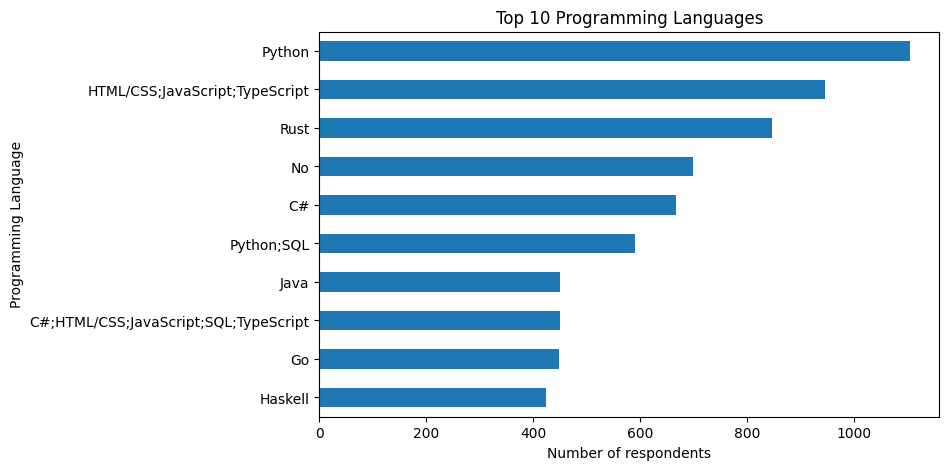

In [66]:
language_counts.head(10).sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)

plt.title('Top 10 Programming Languages')
plt.xlabel('Number of respondents')
plt.ylabel('Programming Language')
plt.show()

###Visualization 2 — Python by Age

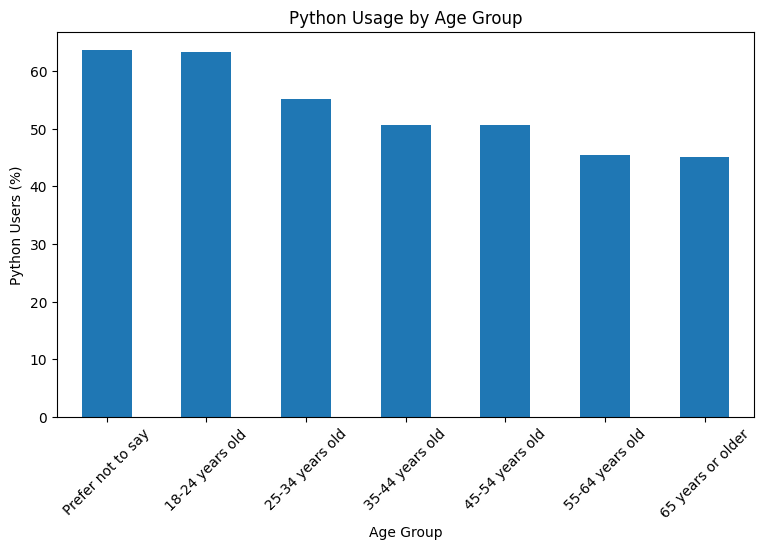

In [65]:
python_by_age = (
    df_clean.groupby('Age')['uses_python']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

python_by_age.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Python Usage by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Python Users (%)')
plt.xticks(rotation=45)
plt.show()

###Visualization 3 — Compensation by Country

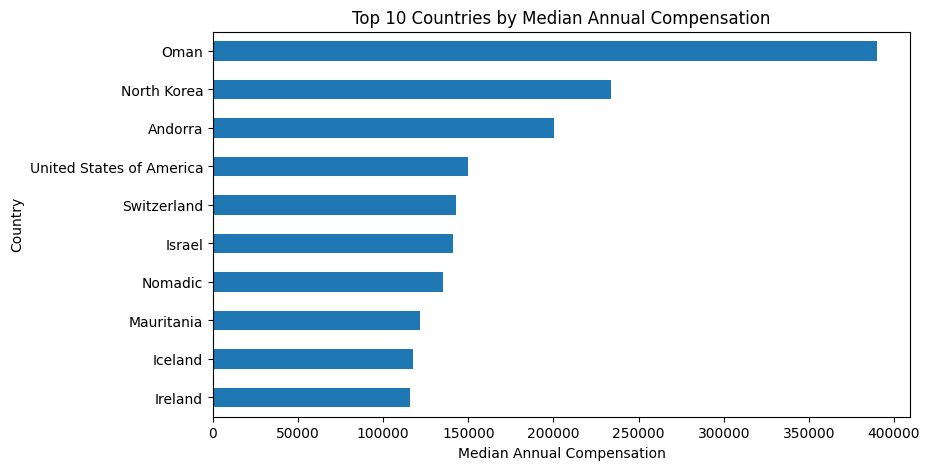

In [64]:
salary_by_country = (
    df_clean.dropna(subset=['Country', 'ConvertedCompYearly'])
    .groupby('Country')['ConvertedCompYearly']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

salary_by_country.sort_values().plot(
    kind='barh',
    figsize=(9, 5)
)

plt.title('Top 10 Countries by Median Annual Compensation')
plt.xlabel('Median Annual Compensation')
plt.ylabel('Country')
plt.show()